Average net salary in June 2026 increased by +0.9% compared to May 2026.
Average net salary in June 2026 increased by +3.5% compared to June 2025.
Highest Earnings by Sector: Activităţi de programare și activități de consultanță în tehnologia informaţiei with 13474 RON and Activităţi de editare with 11999 RON
Lowest Earnings by Sector: Alte activităţi de servicii with 2897 RON and Pescuitul şi acvacultura with 2912 RON


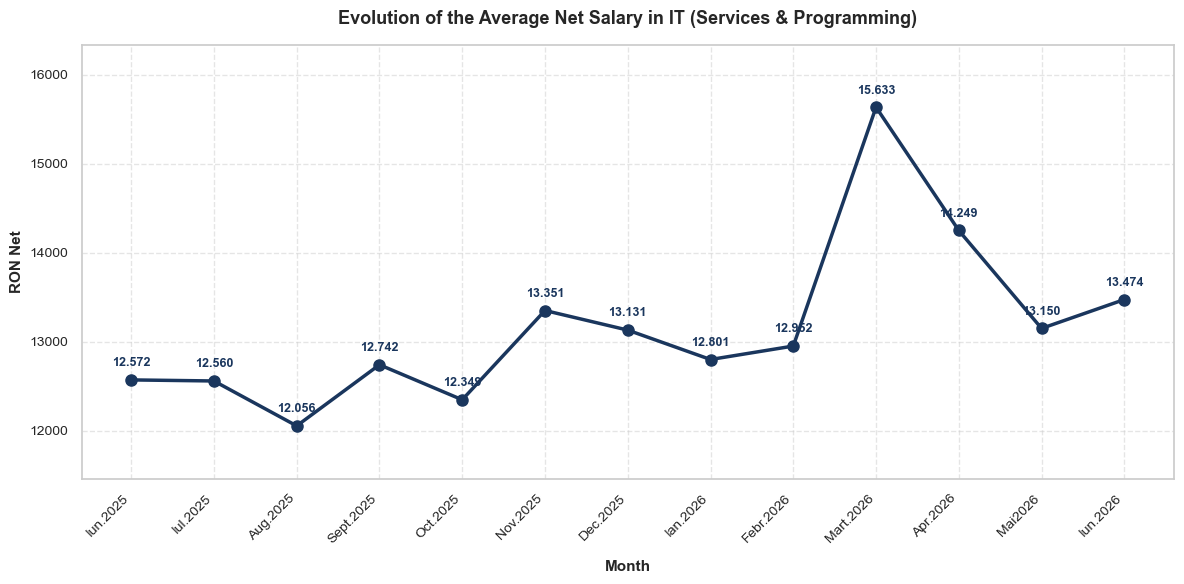

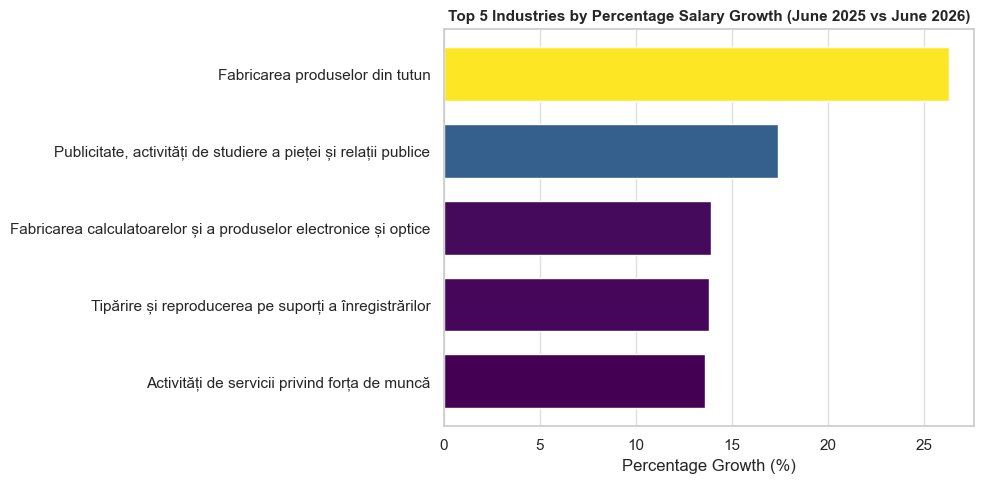

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================
file_path = (
    "C:/Users/AnaTiru/Desktop/Data_Analyst/Curs_data_analyst_SKILLAB/Lectia 20"
    " - 12.08.2026 Interviu/net_salary_ins.xlsx"
)
df = pd.read_excel(file_path)

# ==========================================
# 1. Average net salary in June 2026 compared to May 2026
# ==========================================
iun_2026 = df["Iun.2026"].iloc[0]
mai_2026 = df["Mai2026"].iloc[0]
pct_iun_mai = round(((iun_2026 - mai_2026) / mai_2026) * 100, 1)

print(
    f"Average net salary in June 2026 increased by +{pct_iun_mai}% compared to"
    " May 2026."
)

# ==========================================
# 2. Average net salary in June 2026 compared to June 2025
# ==========================================
iun_2026 = df["Iun.2026"].iloc[0]
iun_2025 = df["Iun.2025"].iloc[0]
pct_iun_iun = round(((iun_2026 - iun_2025) / iun_2025) * 100, 1)

print(
    f"Average net salary in June 2026 increased by +{pct_iun_iun}% compared to"
    " June 2025."
)

# ==========================================
# 3. Highest Earnings by Sector
# ==========================================
order_df_desc = df.sort_values(by="Iun.2026", ascending=False)
highest = order_df_desc.iloc[0:2][["Industry", "Iun.2026"]]

print(
    f"Highest Earnings by Sector: {highest['Industry'].iloc[0]} with"
    f" {highest['Iun.2026'].iloc[0]} RON and {highest['Industry'].iloc[1]} with"
    f" {highest['Iun.2026'].iloc[1]} RON"
)

# ==========================================
# 4. Lowest Earnings by Sector
# ==========================================
order_df_asc = df.sort_values(by="Iun.2026", ascending=True)
lowest = order_df_asc.iloc[0:2][["Industry", "Iun.2026"]]

print(
    f"Lowest Earnings by Sector: {lowest['Industry'].iloc[0]} with"
    f" {lowest['Iun.2026'].iloc[0]} RON and {lowest['Industry'].iloc[1]} with"
    f" {lowest['Iun.2026'].iloc[1]} RON"
)

# ==========================================
# 5. Monthly Evolution of the Net Average Salary in IT (Services & Programming)
# ==========================================
it_salary = df[df["Cod CAEN Rev.3"] == 62]
salaries = it_salary.iloc[0, 2:15].values.astype(int)
months = df.columns[2:15].tolist()

plt.figure(figsize=(12, 6))
plt.plot(
    months, salaries, marker="o", color="#1A365D", linewidth=2.5, markersize=8
)


min_sal = min(salaries)
max_sal = max(salaries)
plt.ylim(min_sal - 600, max_sal + 700)

plt.xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("RON Net", fontsize=11, fontweight="bold")
plt.title(
    "Evolution of the Average Net Salary in IT (Services & Programming)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)


for i, txt in enumerate(salaries):
  plt.annotate(
      f"{txt:,}".replace(",", "."),
      (months[i], salaries[i] + 120),
      ha="center",
      va="bottom",
      fontweight="bold",
      fontsize=9,
      color="#1A365D",
  )

plt.tight_layout()
plt.show()

# ==========================================
# 6. Top 5 Industries by Percentage Salary Growth (June 2025 vs June 2026)
# ==========================================
df["procent"] = round(
    ((df["Iun.2026"] - df["Iun.2025"]) / df["Iun.2025"]) * 100, 1
)
df_proc = df.sort_values(by="procent", ascending=False)
top_5 = df_proc.iloc[0:5]

date = pd.DataFrame({
    "Domeniu": [
        "Fabricarea produselor din tutun",
        "Publicitate, activități de studiere a pieței și relații publice",
        "Fabricarea calculatoarelor și a produselor electronice și optice",
        "Tipărire și reproducerea pe suporți a înregistrărilor",
        "Activități de servicii privind forța de muncă",
    ],
    "Crestere": [26.3, 17.4, 13.9, 13.8, 13.6],
})


date_sorted = date.sort_values(by="Crestere", ascending=True)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")


norm = plt.Normalize(
    date_sorted["Crestere"].min(), date_sorted["Crestere"].max()
)
colors = plt.cm.viridis(norm(date_sorted["Crestere"]))

plt.barh(
    date_sorted["Domeniu"], date_sorted["Crestere"], color=colors, height=0.7
)
plt.title(
    "Top 5 Industries by Percentage Salary Growth (June 2025 vs June 2026)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Percentage Growth (%)")
plt.gca().grid(True, axis="x", color="#E0E0E0")
plt.gca().grid(False, axis="y")

plt.tight_layout()
plt.show()